In [1]:
%load_ext autoreload
%autoreload 2
    
%matplotlib widget
import matplotlib.pyplot as plt
    
# try:
#     import cupy as xp
#     import numpy as np
#     print('Cupy assinged to xp')
# except:
#     import numpy as xp
#     print('Nupy assinged to xp')
import numpy as xp
print('Nupy assinged to xp')

Nupy assinged to xp


# Simple Build  (thin lens+drift)

In [2]:
from rayTEM.elements import Drift1D, Lens1D
from rayTEM.assemblies import MicroscopeSection1D

## build

In [3]:
drift0 = Drift1D(name='drift0', length=1)
lens1 = Lens1D(name='lens1', strength=1, length=0)
drift1 = Drift1D(name='drift1', length=2)
lens2 = Lens1D(name='lens2', strength=1, length=0)
drift2 = Drift1D(name='drift2', length=4)

section1 = MicroscopeSection1D(name='Section1',
                               elements=[
                                   drift0,
                                   lens1, drift1,
                                   lens2, drift2
                               ])
section1

,name,kind,length,position,strength,calibration
0,drift0,drift,1,0.0,0,1.0
1,lens1,Thin Lens,0,1.0,1,NaN
2,drift1,drift,2,1.0,0,1.0
3,lens2,Thin Lens,0,3.0,1,NaN
4,drift2,drift,4,3.0,0,1.0


[[ 1  0]
 [-1  0]
 [ 0  0]] (3, 1, 2)
drift0 (3, 5, 4)
[[[ 1.   0.   0.2  0. ]
  [ 1.   0.   0.4  0. ]
  [ 1.   0.   0.6  0. ]
  [ 1.   0.   0.8  0. ]
  [ 1.   0.   1.   0. ]]

 [[-1.   0.   0.2  0. ]
  [-1.   0.   0.4  0. ]
  [-1.   0.   0.6  0. ]
  [-1.   0.   0.8  0. ]
  [-1.   0.   1.   0. ]]

 [[ 0.   0.   0.2  0. ]
  [ 0.   0.   0.4  0. ]
  [ 0.   0.   0.6  0. ]
  [ 0.   0.   0.8  0. ]
  [ 0.   0.   1.   0. ]]]

1 lens1 1.0
[[[ 1. -1.  1.  0.]]

 [[-1.  1.  1.  0.]]

 [[ 0.  0.  1.  0.]]]

2 drift1 1.0
[[[ 0.6 -1.   1.4  0. ]
  [ 0.2 -1.   1.8  0. ]
  [-0.2 -1.   2.2  0. ]
  [-0.6 -1.   2.6  0. ]
  [-1.  -1.   3.   0. ]]

 [[-0.6  1.   1.4  0. ]
  [-0.2  1.   1.8  0. ]
  [ 0.2  1.   2.2  0. ]
  [ 0.6  1.   2.6  0. ]
  [ 1.   1.   3.   0. ]]

 [[ 0.   0.   1.4  0. ]
  [ 0.   0.   1.8  0. ]
  [ 0.   0.   2.2  0. ]
  [ 0.   0.   2.6  0. ]
  [ 0.   0.   3.   0. ]]]
    flag - last 0

3 lens2 3.0
[[[-1.  0.  3.  0.]]

 [[ 1.  0.  3.  0.]]

 [[ 0.  0.  3.  0.]]]

4 drift2 3.0
[[[-1.   

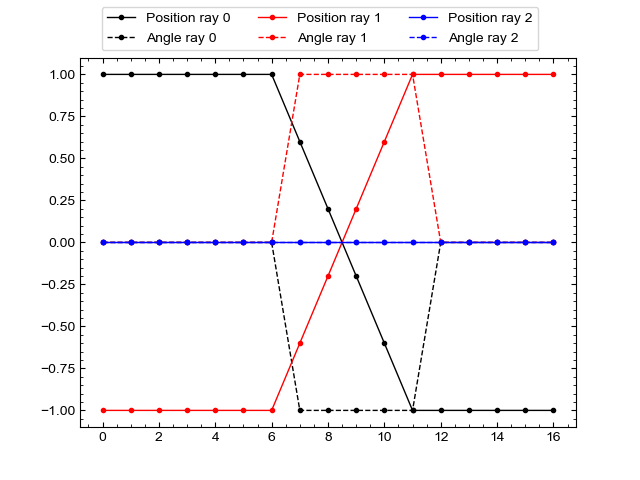

In [5]:
r0 = xp.array([[1,0],
               [-1,0],
               [0,0]])

ri = section1.propogate_ray(r0,
                           z=5
                           )
print('ri',ri.shape)

cs = ['k','r','b']
fig, ax = plt.subplots()
# for ele in section1.elements:
#     if ele.kind != 'drift': ax.axvline(ele.position, ls=':')

for i, path in enumerate(ri):
    ax.plot(path[...,0], ls='-',  c=cs[i], marker='.', label=f'Position ray {i}')
    ax.plot(path[...,1], ls='--', c=cs[i], marker='.', label=f'Angle ray {i}')
fig.legend(ncols=3, loc='upper center')


# Single elements

## Thin lens then manual Drift

In [6]:
from rayTEM.elements import Lens1D, Drift1D

In [7]:
lens = Lens1D(name='ThinLens', length=0, strength=1)
drift = Drift1D(length=2.)

lens, drift

,name,kind,length,strength,calibration
0,ThinLens,Thin Lens,0,1,None


,name,kind,length,strength,calibration
0,,drift,2.0,0,1


(, )

In [8]:
r0 = xp.array([[1,0],
               [-1,0],
               [0,0]])
print('r0',r0.shape)

r0 (3, 2)


r_lens: (3, 1, 4)
[[ 1. -1.  0.  0.]
 [-1.  1.  0.  0.]
 [ 0.  0.  0.  0.]]
ri_drift:  (3, 20, 4)


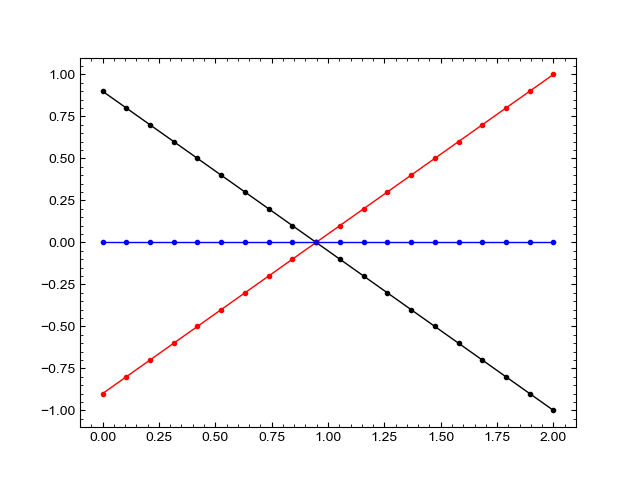

In [9]:
ri = lens.propogate_ray(r0)#, z=20)
print('r_lens:',ri.shape)
print(ri.squeeze())

z = 20#xp.arange(0,2)
ri2 = drift.propogate_ray(ri[:,-1], z=z)
print('ri_drift: ',ri2.shape)

fig, ax = plt.subplots()
for path in ri2[...,0]:
    ax.plot(xp.linspace(0,drift.length, z), path, ls='-', marker='.')

## Quad

In [10]:
from rayTEM.elements import Quadrapole1D

In [11]:
quad = Quadrapole1D(name='Quad',# poles=4,
                     length=10,
                     strength=0.2)
quad

,name,kind,length,strength,calibration
0,Quad,Quad,10,0.2,None


In [12]:
r0 = xp.array([[1,-1],
               [-1,1],
               [0,0]])
print('r0',r0.shape)

r0 (3, 2)


ri (3, 20, 4)


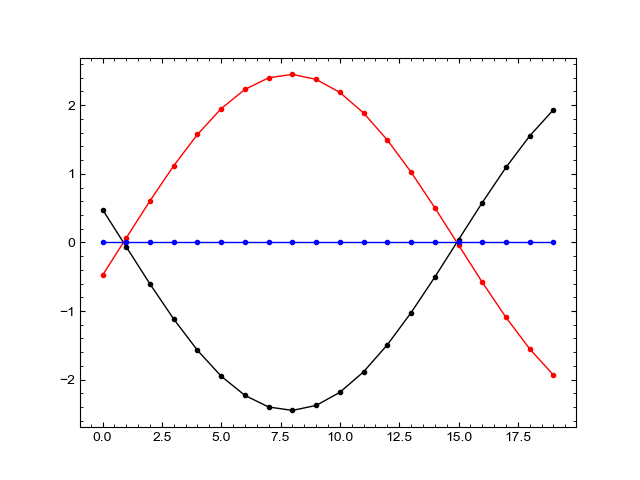

In [13]:
ri = quad.propogate_ray(r0, z=20)
print('ri',ri.shape)

fig, ax = plt.subplots()
for path, s in zip(ri[...,0], r0[...,0]):
    ax.plot(path, ls='-', marker='.')

## 2D Thin lens

In [14]:
from rayTEM.elements import Lens, Drift

In [15]:
r0 = xp.array([[1,0,0,0,0,0],
               [-1,0,0,0,0,0],
               [0,0,0,0,0,0]])
lens = Lens(name='Lens1', length=0, strength=1)
drift = Drift(length=2.)

s lens [0]
r_lens: (3, 1, 6)
[[ 1. -1.  0.  0.  0.  0.]
 [-1.  1.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.]]
ri_drift:  (3, 5, 6)


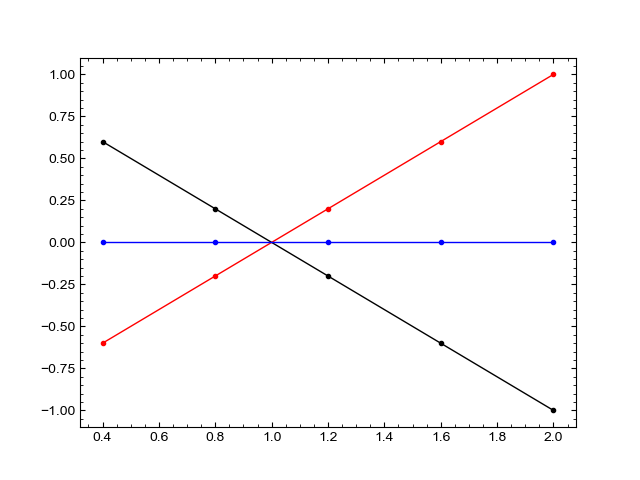

In [22]:
ri = lens.propogate_ray(r0)#, z=5)
print('r_lens:',ri.shape)
print(ri.squeeze())

z = 5#xp.arange(0,2)
ri2 = drift.propogate_ray(ri[:,-1], z=z)
print('ri_drift: ',ri2.shape)

fig, ax = plt.subplots()
for path in ri2[...,0]:
    ax.plot(xp.linspace(0,drift.length, z+1)[1:], path, ls='-', marker='.')

# Simple Build 2D

## Build

In [17]:
from rayTEM.elements import Lens, Drift
from rayTEM.assemblies import MicroscopeSection

In [18]:
rays = xp.array([[1,0,0,0,0,0],
                 #[-1,0,0,0,0,0], 
                 #[0,0,0,0,0,0],
                 ])


In [19]:
drift0 = Drift(name='drift0', length=1)
lens1 = Lens(name='lens1', strength=1, length=0)
drift1 = Drift(name='drift1', length=2)
lens2 = Lens(name='lens2', strength=1, length=0)
drift2 = Drift(name='drift2', length=4)

section1 = MicroscopeSection(name='Section1',
                               elements=[
                                   drift0,
                                   lens1, drift1,
                                   lens2, drift2
                               ])
section1

,name,kind,length,position,strength,calibration
0,drift0,Drift,1,0.0,0.0,None
1,lens1,Thin lens,0,1.0,1.0,None
2,drift1,Drift,2,1.0,0.0,None
3,lens2,Thin lens,0,3.0,1.0,None
4,drift2,Drift,4,3.0,0.0,None


The below works is working but for some reason the angles are one step behind

In [20]:
ri = section1.propogate_ray(rays, z=5)

[[1 0 0 0 0 0]] (1, 1, 6)
drift0 (1, 5, 6)
[[[1.  0.  0.  0.  0.2 0. ]
  [1.  0.  0.  0.  0.4 0. ]
  [1.  0.  0.  0.  0.6 0. ]
  [1.  0.  0.  0.  0.8 0. ]
  [1.  0.  0.  0.  1.  0. ]]]

s lens [0.]
1 lens1 1.0
[[[ 1. -1.  0.  0.  1.  0.]]]

2 drift1 1.0
[[[ 0.6 -1.   0.   0.   1.4  0. ]
  [ 0.2 -1.   0.   0.   1.8  0. ]
  [-0.2 -1.   0.   0.   2.2  0. ]
  [-0.6 -1.   0.   0.   2.6  0. ]
  [-1.  -1.   0.   0.   3.   0. ]]]
    flag - last 0

s lens [0.]
3 lens2 3.0
[[[-1.  0.  0.  0.  3.  0.]]]

4 drift2 3.0
[[[-1.   0.   0.   0.   3.8  0. ]
  [-1.   0.   0.   0.   4.6  0. ]
  [-1.   0.   0.   0.   5.4  0. ]
  [-1.   0.   0.   0.   6.2  0. ]
  [-1.   0.   0.   0.   7.   0. ]]]
    flag - last 0



c:\users\e81\documents\github\raytem\rayTEM\elements.py:98: UserWarning: z was provided for a zero length element and will not be used.
  warn('z was provided for a zero length element and will not be used.')


## Plot

In [21]:
cs = ['k','r','b']
fig, ax = plt.subplots()
# for ele in section1.elements:
#     if ele.kind != 'drift': ax.axvline(ele.position, ls=':')

for i, path in enumerate(ri):
    ax.plot(path[...,-2], path[...,0], ls='-',  c=cs[i], marker='.', label=f'Position ray {i}')
    ax.plot(path[...,-2], path[...,1], ls='--', c=cs[i], marker='.', label=f'Angle ray {i}')

for ele in section1.elements:
    ax.axvline(ele.position, ls=':', c='gray', lw=0.5, label=ele.name)
fig.legend(ncols=3, loc='upper center')


section1

,name,kind,length,position,strength,calibration
0,drift0,Drift,1,0.0,0.0,None
1,lens1,Thin lens,0,1.0,1.0,None
2,drift1,Drift,2,1.0,0.0,None
3,lens2,Thin lens,0,3.0,1.0,None
4,drift2,Drift,4,3.0,0.0,None
